# Base 1 — Bitcoin (BTC)

In [1]:
from pathlib import Path
import hashlib
import json
import math
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')

ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / 'src'))
from series_temporais.features.temporal import (
    build_one_step_frame, chronological_train_test, longest_observed_run,
)
from series_temporais.validation.temporal_split import purged_time_series_splits

BASE_NUMBER = 1
BASE_DIR = ROOT / 'trabalho' / 'bases' / 'grupo1'
DATA_PATH = BASE_DIR / 'base1_limpa_preparada.csv'
TIME_COL = 'Date'
TARGET_COL = 'Close'
EXTERNAL_COLS = ['Open', 'High', 'Low', 'Volume']
EXPECTED_STEP = pd.Timedelta('1D')
FREQUENCY = 'D'
TRAIN_RATIO = 0.7
LAGS = [1, 2, 3, 7, 14, 30]
WINDOWS = [7, 14, 30]
STL_PERIODS = {'semanal (7 dias)': 7, 'anual (365 dias)': 365}
STL_ROBUST = True
ACF_LAGS = 30
LJUNG_LAGS = [1, 7, 14, 30]
TUNING_MAX_ROWS = None
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Limpeza e preparação reutilizadas


In [2]:
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = pd.read_csv(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='raise')
df = df.sort_values(TIME_COL, kind='stable').reset_index(drop=True)
assert df[TIME_COL].is_monotonic_increasing and df[TIME_COL].is_unique
audit = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'inicio': df[TIME_COL].min(), 'fim': df[TIME_COL].max(),
    'nulos_alvo': int(df[TARGET_COL].isna().sum()),
    'timestamps_duplicados': int(df[TIME_COL].duplicated().sum()),
}, name='valor').to_frame()
display(audit)
display(df.head())

,valor
arquivo,trabalho\bases\grupo1\base1_limpa_preparada.csv
sha256,b8747ed74049875f4892d1f6307d05b6b11437e7ccfb21...
linhas,2836
colunas,7
inicio,2017-01-01 00:00:00
fim,2024-10-06 00:00:00
nulos_alvo,0
timestamps_duplicados,0


,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-01-01,963.658020,1003.080017,958.698975,998.325012,998.325012,147775008
1,2017-01-02,998.617004,1031.390015,996.702026,1021.750000,1021.750000,222184992
2,2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,1043.839966,185168000
3,2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,1154.729980,344945984
4,2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,1013.380005,510199008


## 3. Gráficos exploratórios reaproveitados

Reproduzimos os mesmos eixos centrais dos notebooks exploratórios: série
completa, trecho recente, distribuição, padrão de calendário,
ausências e as principais variáveis externas. Picos não são
removidos automaticamente.

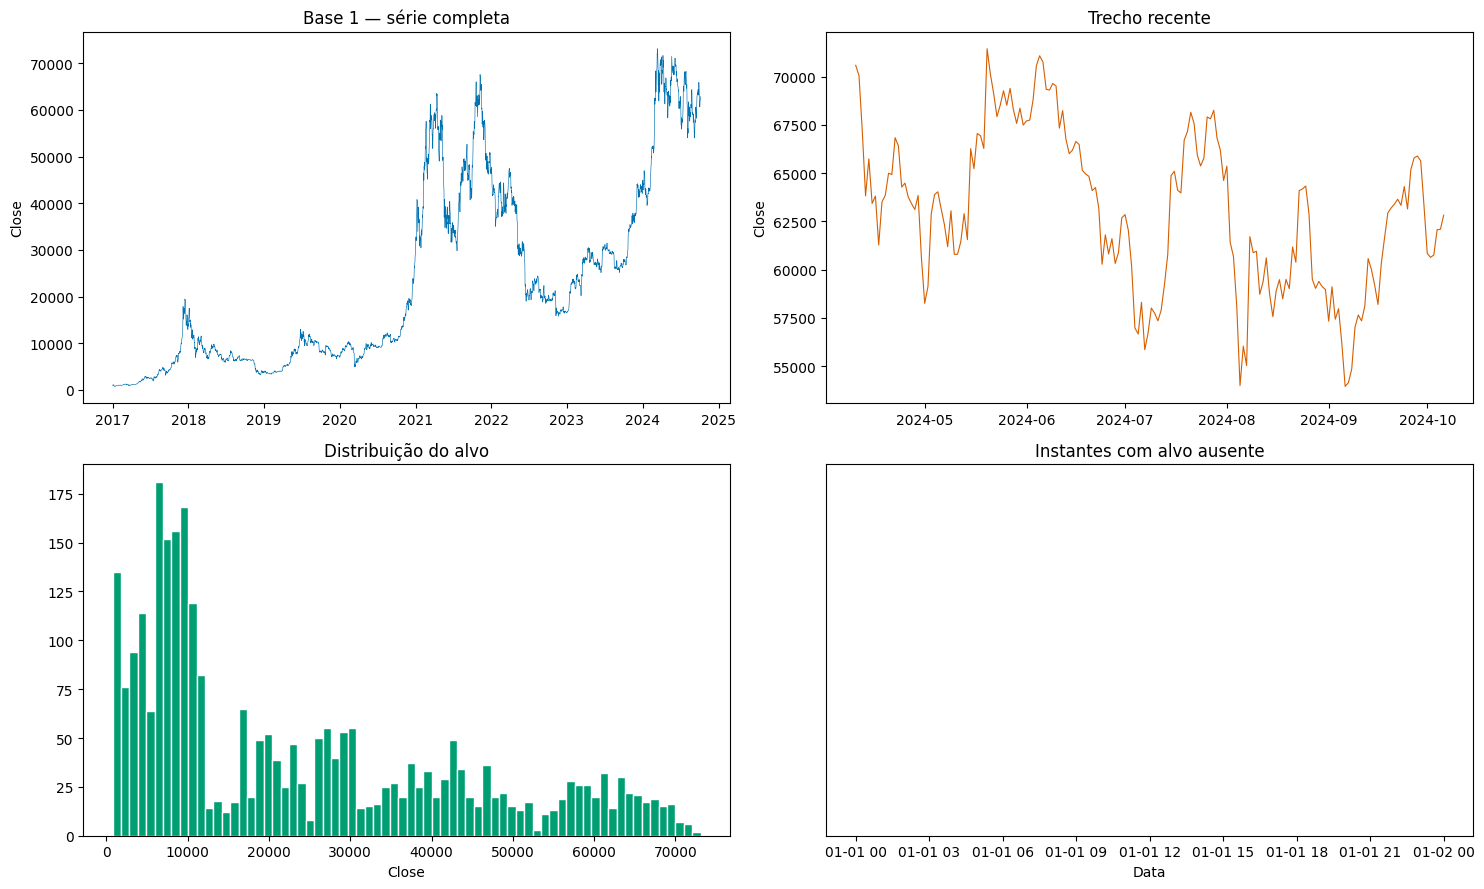

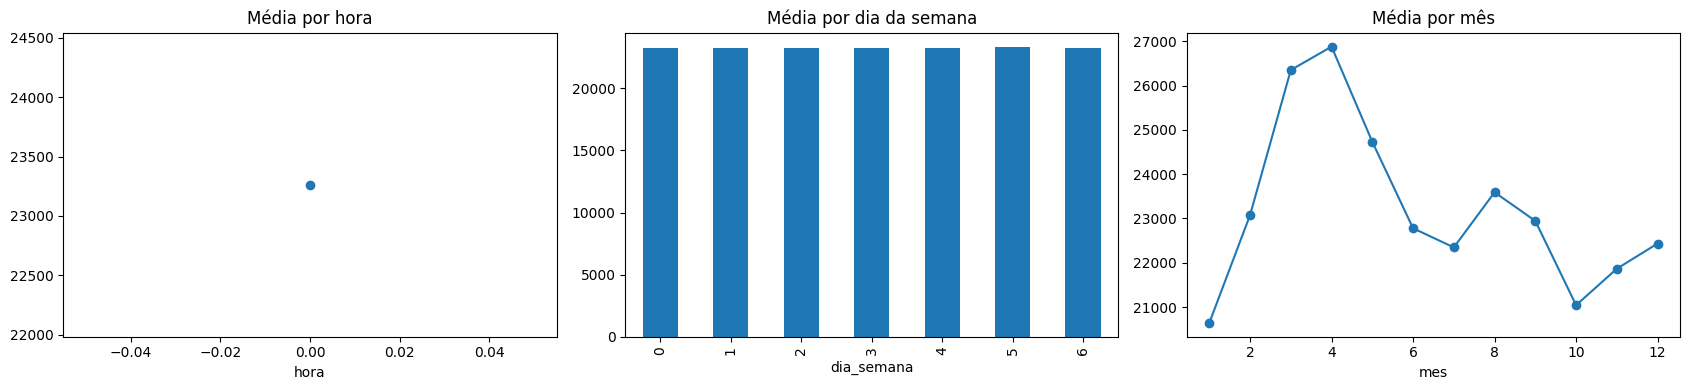

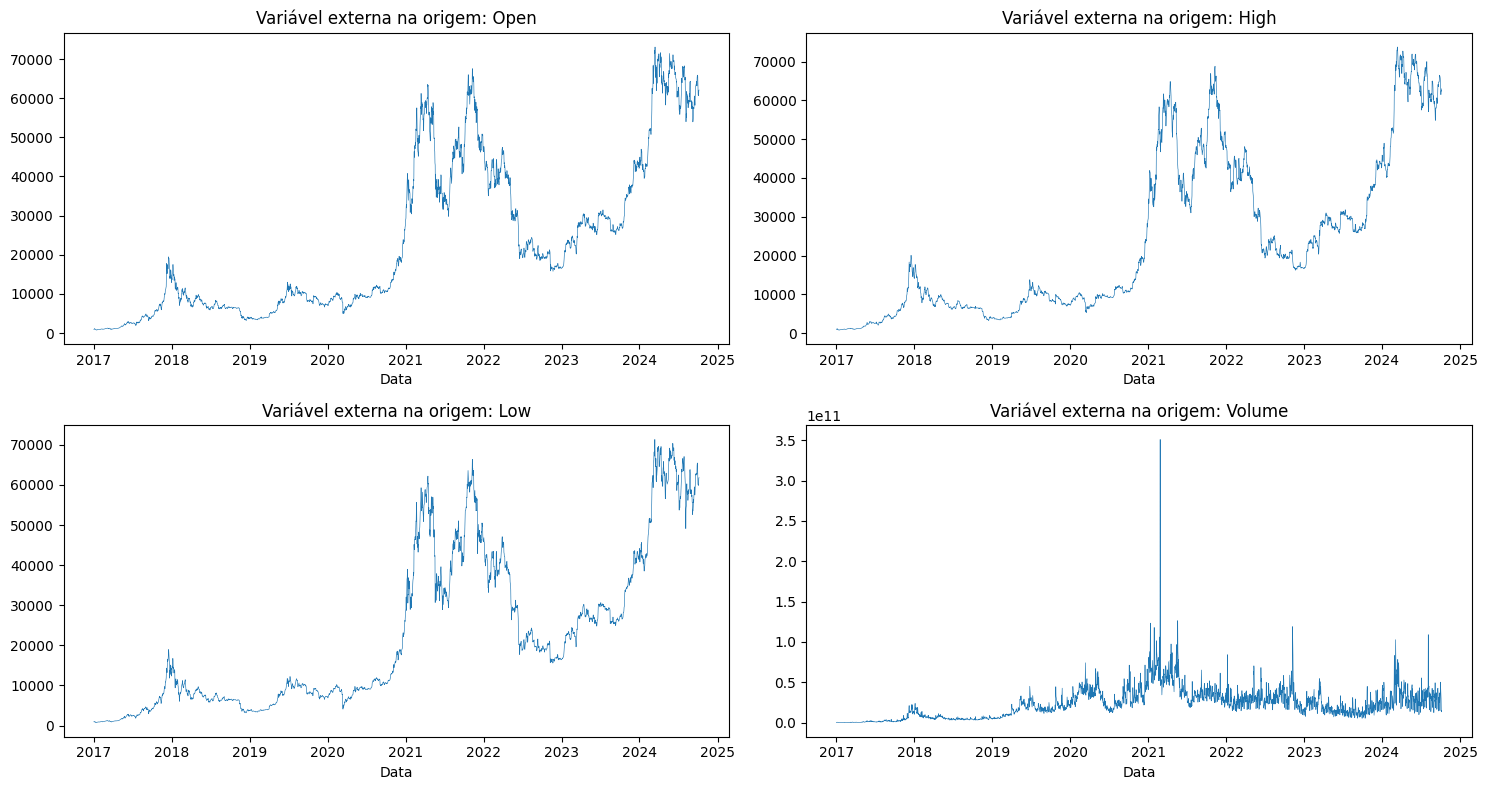

In [3]:
observed = df.dropna(subset=[TARGET_COL]).copy()
recent = observed.tail(180)
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0, 0].plot(observed[TIME_COL], observed[TARGET_COL], lw=.45, color='#0072b2')
axes[0, 0].set(title=f'Base {BASE_NUMBER} — série completa', ylabel=TARGET_COL)
axes[0, 1].plot(recent[TIME_COL], recent[TARGET_COL], lw=.8, color='#d55e00')
axes[0, 1].set(title='Trecho recente', ylabel=TARGET_COL)
axes[1, 0].hist(observed[TARGET_COL], bins=70, edgecolor='white', color='#009e73')
axes[1, 0].set(title='Distribuição do alvo', xlabel=TARGET_COL)
axes[1, 1].scatter(df.loc[df[TARGET_COL].isna(), TIME_COL], np.ones(df[TARGET_COL].isna().sum()), s=4)
axes[1, 1].set(title='Instantes com alvo ausente', xlabel='Data', yticks=[])
plt.tight_layout(); plt.show()

calendar = observed.assign(
    hora=observed[TIME_COL].dt.hour,
    dia_semana=observed[TIME_COL].dt.dayofweek,
    mes=observed[TIME_COL].dt.month,
)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
calendar.groupby('hora')[TARGET_COL].mean().plot(ax=axes[0], marker='o', title='Média por hora')
calendar.groupby('dia_semana')[TARGET_COL].mean().plot.bar(ax=axes[1], title='Média por dia da semana')
calendar.groupby('mes')[TARGET_COL].mean().plot(ax=axes[2], marker='o', title='Média por mês')
plt.tight_layout(); plt.show()

external_to_plot = ['Open', 'High', 'Low', 'Volume']
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, column in zip(axes.flat, external_to_plot, strict=True):
    ax.plot(df[TIME_COL], df[column], lw=.45)
    ax.set(title=f'Variável externa na origem: {column}', xlabel='Data')
plt.tight_layout(); plt.show()

## 4. STL e força da sazonalidade

A STL usa somente a janela cronológica de treino e o maior trecho
contínuo sem ausências. Não há interpolação do alvo. Isso evita criar
ciclos artificiais em lacunas longas. A força é
`max(0, 1 - Var(R) / Var(S + R))`.

,periodo,observacoes_por_ciclo,forca_sazonalidade,forca_tendencia,ausencias_no_treino_nao_interpoladas,pontos_no_trecho_continuo,inicio_trecho,fim_trecho
0,semanal (7 dias),7,0.0,0.994198,0,1985,2017-01-01,2022-06-08
1,anual (365 dias),365,0.0,0.741431,0,1985,2017-01-01,2022-06-08


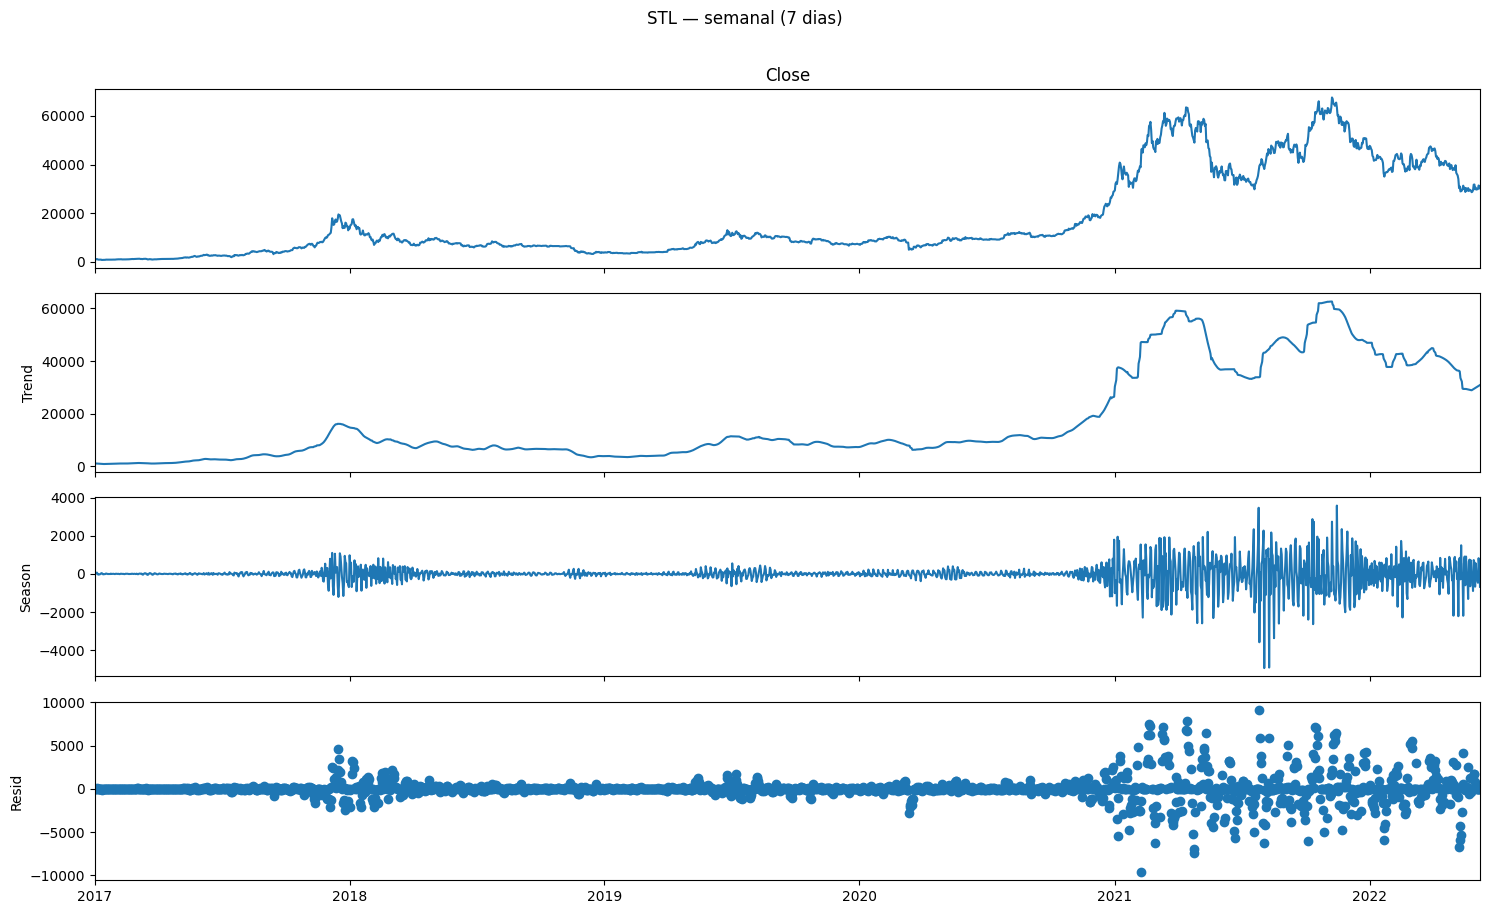

Interpretação: a maior força sazonal foi 0.000 no ciclo semanal (7 dias). No componente exibido, a tendência varia 29818.698 unidades no período, com crescimento líquido. Oscilações do resíduo representam variação não explicada por tendência e sazonalidade; a leitura de mudanças locais deve ser feita diretamente no gráfico.


In [4]:
split_time = df[TIME_COL].iloc[int(len(df) * TRAIN_RATIO)]
stl_series = df.loc[df[TIME_COL] < split_time, [TIME_COL, TARGET_COL]].set_index(TIME_COL)[TARGET_COL]
stl_series = stl_series.asfreq(FREQUENCY)
missing_for_stl = int(stl_series.isna().sum())
minimum_stl_rows = 2 * max(STL_PERIODS.values())
stl_series = longest_observed_run(stl_series, minimum_stl_rows)
stl_rows, stl_results = [], {}
for label, period in STL_PERIODS.items():
    result = STL(stl_series, period=period, robust=STL_ROBUST).fit()
    stl_results[label] = result
    resid_var = np.var(result.resid, ddof=1)
    seasonal_den = np.var(result.seasonal + result.resid, ddof=1)
    trend_den = np.var(result.trend + result.resid, ddof=1)
    stl_rows.append({
        'periodo': label, 'observacoes_por_ciclo': period,
        'forca_sazonalidade': max(0., 1. - resid_var / seasonal_den),
        'forca_tendencia': max(0., 1. - resid_var / trend_den),
        'ausencias_no_treino_nao_interpoladas': missing_for_stl,
        'pontos_no_trecho_continuo': len(stl_series),
        'inicio_trecho': stl_series.index.min(),
        'fim_trecho': stl_series.index.max(),
    })
stl_strength = pd.DataFrame(stl_rows)
display(stl_strength)
selected_label = list(STL_PERIODS)[0]
selected = stl_results[selected_label]
fig = selected.plot(); fig.set_size_inches(15, 9)
fig.suptitle(f'STL — {selected_label}', y=1.01); plt.tight_layout(); plt.show()
strongest = stl_strength.sort_values('forca_sazonalidade', ascending=False).iloc[0]
trend_change = float(selected.trend.iloc[-1] - selected.trend.iloc[0])
trend_direction = 'crescimento líquido' if trend_change > 0 else 'queda líquida' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: a maior força sazonal foi {strongest.forca_sazonalidade:.3f} '
    f'no ciclo {strongest.periodo}. No componente exibido, a tendência varia '
    f'{abs(trend_change):.3f} unidades no período, com {trend_direction}. '
    'Oscilações do resíduo representam variação não explicada por tendência e sazonalidade; '
    'a leitura de mudanças locais deve ser feita diretamente no gráfico.'
)

## 5. Features e corte temporal

A origem `t` usa o alvo e as medições disponíveis em `t`, lags, janelas
históricas e calendário de `t+1`. Só permanecem pares cuja data-alvo está
exatamente um passo depois da origem. O regressor aprende a variação até
`t+1`; o nível é reconstruído para avaliar MAE na unidade original.

In [5]:
model_df, feature_columns = build_one_step_frame(
    df, time_col=TIME_COL, target_col=TARGET_COL, external_cols=EXTERNAL_COLS,
    expected_step=EXPECTED_STEP, lags=LAGS, windows=WINDOWS,
)
train_df, test_df = chronological_train_test(model_df, TRAIN_RATIO)
X_train, y_train = train_df[feature_columns], train_df.target_delta
X_test, y_test = test_df[feature_columns], test_df.target_delta
assert train_df.target_time.max() < test_df.origin_time.min()
assert not {'y_true', 'target_delta', 'target_time'}.intersection(feature_columns)
display(pd.DataFrame({
    'recorte': ['treino', 'teste'], 'linhas': [len(train_df), len(test_df)],
    'primeira_origem': [train_df.origin_time.min(), test_df.origin_time.min()],
    'última_origem': [train_df.origin_time.max(), test_df.origin_time.max()],
}))
print(f'{len(feature_columns)} features:', feature_columns)

,recorte,linhas,primeira_origem,última_origem
0,treino,1962,2017-01-31,2022-06-15
1,teste,842,2022-06-17,2024-10-05


23 features: ['level_t', 'Open_t', 'High_t', 'Low_t', 'Volume_t', 'target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_7', 'target_lag_14', 'target_lag_30', 'target_mean_7', 'target_std_7', 'target_mean_14', 'target_std_14', 'target_mean_30', 'target_std_30', 'target_hour_sin', 'target_hour_cos', 'target_dow_sin', 'target_dow_cos', 'target_month_sin', 'target_month_cos']


## 6. Otimização temporal do Random Forest

O desenho abaixo investiga `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em dobras
expansivas purgadas. A Base 4 limita o tuning às 60 mil linhas de treino
mais recentes por custo; o ajuste final continua usando todo o histórico.

In [6]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
tuning = train_df.tail(TUNING_MAX_ROWS).reset_index(drop=True) if TUNING_MAX_ROWS else train_df
tuning_X, tuning_y = tuning[feature_columns], tuning.target_delta
cv_splits = purged_time_series_splits(tuning.origin_time, tuning.target_time, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        model.fit(tuning_X.iloc[fit_idx], tuning_y.iloc[fit_idx])
        prediction = model.predict(tuning_X.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(tuning_y.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae_delta': np.mean(fold_maes),
        'std_validation_mae_delta': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae_delta', 'std_validation_mae_delta', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae_delta,std_validation_mae_delta,fit_seconds
0,5,100,NaN,2,3,sqrt,661.560357,580.868150,12.944132
1,7,200,12.0,10,3,0.7,674.008314,619.253022,26.302254
2,8,200,20.0,5,2,0.7,738.010868,714.005988,41.577066
3,1,100,NaN,2,1,sqrt,742.029577,677.045163,10.969939
4,2,200,NaN,2,1,sqrt,750.955478,705.982655,11.965025
5,4,100,NaN,10,1,sqrt,775.760309,750.219312,15.082281
6,3,100,12.0,2,1,sqrt,812.908634,832.737864,9.201389
7,6,100,NaN,2,1,0.7,1091.752738,1283.071001,21.881737


Melhores parâmetros: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo de busca: 150.44 s


## 7. Walk-forward final e importância das features

Os parâmetros escolhidos ficam fixos. O modelo é reajustado periodicamente
em oito blocos por limitação computacional; cada origem ainda recebe uma
previsão fora da amostra com suas features disponíveis. Em cada reajuste,
entram apenas alvos estritamente anteriores à origem. Este cronograma é
provisório e deverá ser igualado aos demais modelos no protocolo final.

,origin_time,target_time,level_t,y_true,target_delta,y_pred_delta_rf,model_refit_origin,training_target_cutoff,y_pred_rf,y_pred_persistencia,residuo_rf,erro_absoluto_rf,erro_quadratico_rf
0,2022-06-17,2022-06-18,20471.482422,19017.642578,-1453.839844,-400.756882,2022-06-17,2022-06-16,20070.725539,20471.482422,-1053.082961,1053.082961,1.108984e+06
1,2022-06-18,2022-06-19,19017.642578,20553.271484,1535.628906,-66.641554,2022-06-17,2022-06-16,18951.001024,19017.642578,1602.270461,1602.270461,2.567271e+06
2,2022-06-19,2022-06-20,20553.271484,20599.537109,46.265625,107.300057,2022-06-17,2022-06-16,20660.571541,20553.271484,-61.034432,61.034432,3.725202e+03
3,2022-06-20,2022-06-21,20599.537109,20710.597656,111.060547,54.300313,2022-06-17,2022-06-16,20653.837423,20599.537109,56.760234,56.760234,3.221724e+03
4,2022-06-21,2022-06-22,20710.597656,19987.029297,-723.568359,-99.668040,2022-06-17,2022-06-16,20610.929617,20710.597656,-623.900320,623.900320,3.892516e+05


,feature,importance_mean,importance_std,grupo
0,target_std_7,0.073530,0.004423,historico_do_alvo
1,target_lag_30,0.064409,0.004049,historico_do_alvo
2,target_std_30,0.063050,0.005070,historico_do_alvo
3,target_std_14,0.062292,0.002493,historico_do_alvo
4,Volume_t,0.058413,0.003008,externa_na_origem
5,level_t,0.054375,0.001327,estado_atual_ou_calendario
6,Low_t,0.053736,0.002519,externa_na_origem
7,target_lag_3,0.053338,0.002093,historico_do_alvo
8,High_t,0.053265,0.002405,externa_na_origem
9,target_lag_2,0.052734,0.002689,historico_do_alvo


,grupo,importance_mean
0,estado_atual_ou_calendario,0.054375
1,externa_na_origem,0.211651
2,historico_do_alvo,0.733974


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
4,Volume_t,0.058413,0.003008,externa_na_origem
6,Low_t,0.053736,0.002519,externa_na_origem
8,High_t,0.053265,0.002405,externa_na_origem
14,Open_t,0.046238,0.001785,externa_na_origem


Disponibilidade: estas externas são usadas no estado observado da origem t para prever t+1; valores observados em t+1 nunca entram em X.


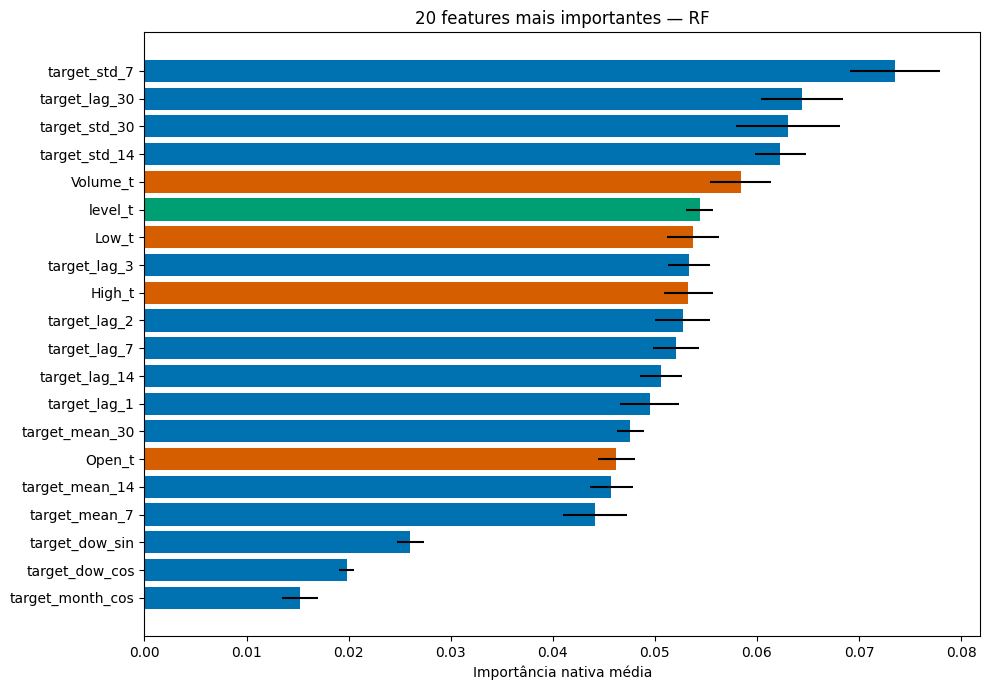

In [7]:
refit_every = max(1, math.ceil(len(test_df) / 8))
predictions_list, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), refit_every):
    block_end = min(block_start + refit_every, len(test_df))
    current_origin = test_df.iloc[block_start].origin_time
    known_test = test_df.target_time < current_origin
    history = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history.target_delta)
    predictions_list.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_time.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_treino': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[['origin_time', 'target_time', 'level_t', 'y_true', 'target_delta']].copy()
predictions['y_pred_delta_rf'] = np.asarray(predictions_list)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff < predictions.origin_time).all()
predictions['y_pred_rf'] = predictions.level_t + predictions.y_pred_delta_rf
predictions['y_pred_persistencia'] = predictions.level_t
predictions['residuo_rf'] = predictions.y_true - predictions.y_pred_rf
predictions['erro_absoluto_rf'] = predictions.residuo_rf.abs()
predictions['erro_quadratico_rf'] = predictions.residuo_rf.pow(2)
fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_feature_names = {f'{column}_t' for column in EXTERNAL_COLS}
feature_importance['grupo'] = np.select(
    [feature_importance.feature.isin(external_feature_names),
     feature_importance.feature.str.startswith('target_')],
    ['externa_na_origem', 'historico_do_alvo'], default='estado_atual_ou_calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
top_external = feature_importance.loc[
    feature_importance.grupo.eq('externa_na_origem')
].head(5)
print('Externas mais importantes (importância nativa, não causal):')
display(top_external)
print(
    'Disponibilidade: estas externas são usadas no estado observado da origem t '
    'para prever t+1; valores observados em t+1 nunca entram em X.'
)
colors = feature_importance.head(20).grupo.map({
    'externa_na_origem': '#d55e00', 'historico_do_alvo': '#0072b2',
    'estado_atual_ou_calendario': '#009e73',
})
top = feature_importance.head(20).sort_values('importance_mean')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=colors.loc[top.index])
ax.set(title='20 features mais importantes — RF', xlabel='Importância nativa média')
plt.tight_layout(); plt.show()

## 8. MAE e demais métricas

O MAE principal é calculado fora da amostra no nível e na unidade original.
A persistência (`ŷ(t+1)=y(t)`) torna explícito se o RF agrega valor.

In [8]:
def metric_row(name, values):
    values = np.asarray(values)
    return {
        'modelo': name,
        'MAE': mean_absolute_error(predictions.y_true, values),
        'RMSE': mean_squared_error(predictions.y_true, values) ** .5,
        'MedAE': median_absolute_error(predictions.y_true, values),
        'R2': r2_score(predictions.y_true, values),
        'vies_medio': np.mean(predictions.y_true - values),
    }
metrics = pd.DataFrame([
    metric_row('Random Forest', predictions.y_pred_rf),
    metric_row('Persistência', predictions.y_pred_persistencia),
])
display(metrics)

,modelo,MAE,RMSE,MedAE,R2,vies_medio
0,Random Forest,764.717551,1186.796076,447.573956,0.995554,162.353941
1,Persistência,693.433902,1117.845413,385.301758,0.996056,50.293908


## 9. Registro de parâmetros, versões e tempo


In [9]:
experiment_record = pd.DataFrame([{
    'base': 'Base 1 — Bitcoin (BTC)',
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'frequencia': FREQUENCY, 'alvo_original': TARGET_COL,
    'alvo_modelo': 'delta de um passo', 'horizonte_provisorio': str(EXPECTED_STEP),
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino': len(train_df), 'linhas_teste': len(test_df),
    'origem_teste_inicial': test_df.origin_time.min(),
    'origem_teste_final': test_df.origin_time.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'linhas_usadas_tuning': len(tuning),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 1 — Bitcoin (BTC)
arquivo,trabalho\bases\grupo1\base1_limpa_preparada.csv
sha256,b8747ed74049875f4892d1f6307d05b6b11437e7ccfb21...
frequencia,D
alvo_original,Close
alvo_modelo,delta de um passo
horizonte_provisorio,1 days 00:00:00
split_treino,0.7
random_state,42
linhas_treino,1962


,origem_refit,linhas_treino,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2022-06-17,1962,0,106,5.396448
1,2022-10-01,2067,106,212,6.706581
2,2023-01-15,2173,212,318,7.807778
3,2023-05-01,2279,318,424,4.128068
4,2023-08-15,2385,424,530,7.894331
5,2023-11-29,2491,530,636,16.629893
6,2024-03-14,2597,636,742,13.524240
7,2024-06-28,2703,742,842,10.447321


## 10. Resíduos individuais

Cada origem do teste possui previsão, resíduo e erros individuais. O gráfico
permite verificar viés, mudanças de dispersão e períodos de deterioração.

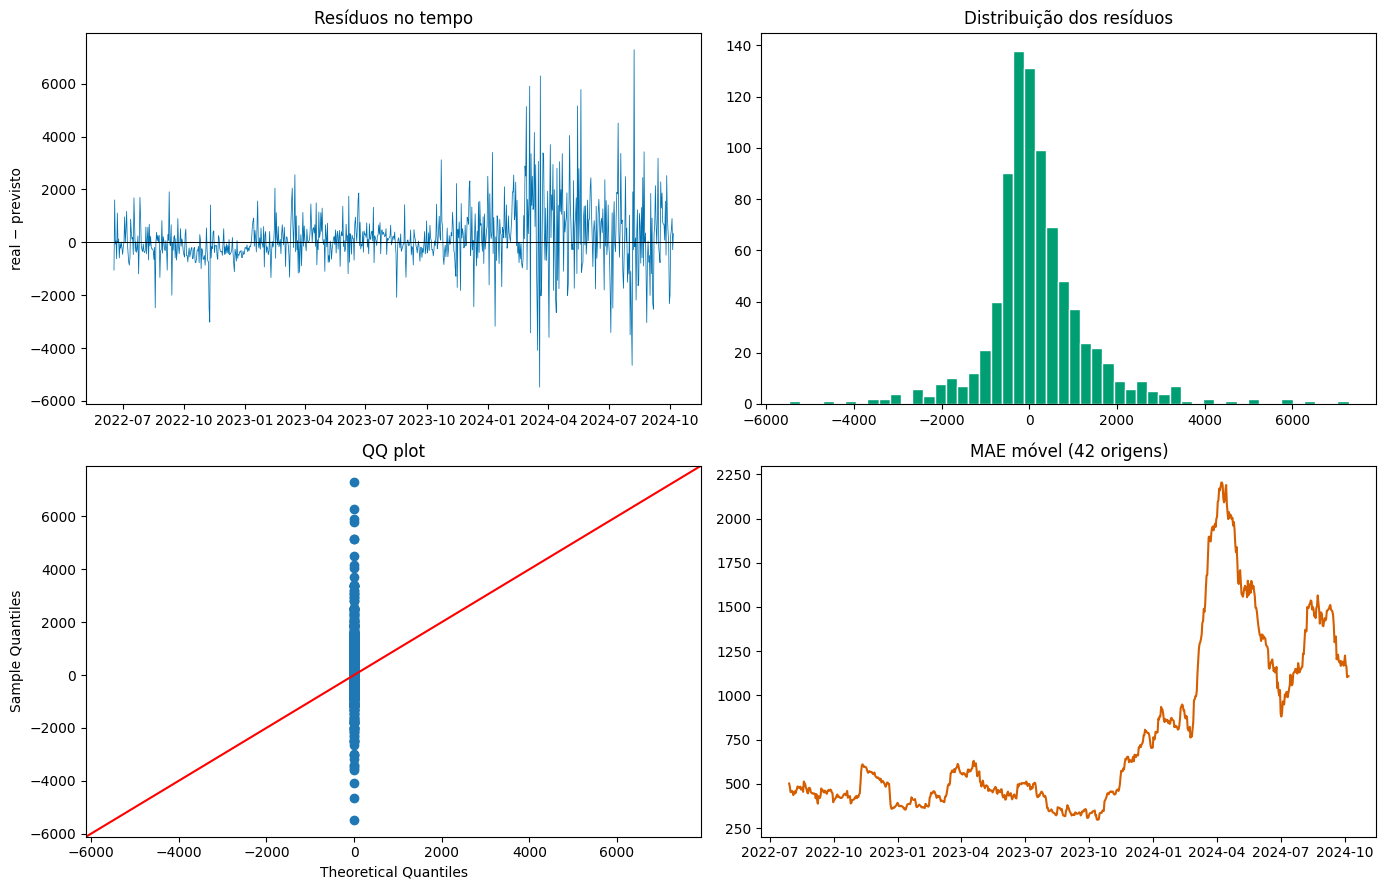

,origin_time,target_time,level_t,y_true,target_delta,y_pred_delta_rf,model_refit_origin,training_target_cutoff,y_pred_rf,y_pred_persistencia,residuo_rf,erro_absoluto_rf,erro_quadratico_rf
0,2022-06-17,2022-06-18,20471.482422,19017.642578,-1453.839844,-400.756882,2022-06-17,2022-06-16,20070.725539,20471.482422,-1053.082961,1053.082961,1.108984e+06
1,2022-06-18,2022-06-19,19017.642578,20553.271484,1535.628906,-66.641554,2022-06-17,2022-06-16,18951.001024,19017.642578,1602.270461,1602.270461,2.567271e+06
2,2022-06-19,2022-06-20,20553.271484,20599.537109,46.265625,107.300057,2022-06-17,2022-06-16,20660.571541,20553.271484,-61.034432,61.034432,3.725202e+03
3,2022-06-20,2022-06-21,20599.537109,20710.597656,111.060547,54.300313,2022-06-17,2022-06-16,20653.837423,20599.537109,56.760234,56.760234,3.221724e+03
4,2022-06-21,2022-06-22,20710.597656,19987.029297,-723.568359,-99.668040,2022-06-17,2022-06-16,20610.929617,20710.597656,-623.900320,623.900320,3.892516e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,2024-10-01,2024-10-02,60837.007812,60632.785156,-204.222656,-467.845355,2024-06-28,2024-06-27,60369.162457,60837.007812,263.622699,263.622699,6.949693e+04
838,2024-10-02,2024-10-03,60632.785156,60759.402344,126.617188,-351.411886,2024-06-28,2024-06-27,60281.373270,60632.785156,478.029073,478.029073,2.285118e+05
839,2024-10-03,2024-10-04,60759.402344,62067.476562,1308.074219,407.945923,2024-06-28,2024-06-27,61167.348266,60759.402344,900.128296,900.128296,8.102309e+05
840,2024-10-04,2024-10-05,62067.476562,62089.949219,22.472656,302.458500,2024-06-28,2024-06-27,62369.935062,62067.476562,-279.985844,279.985844,7.839207e+04


In [10]:
residuals = predictions.residuo_rf
rolling_window = max(5, len(predictions) // 20)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(predictions.target_time, residuals, lw=.55, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=50, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(predictions.target_time, predictions.erro_absoluto_rf.rolling(rolling_window).mean(), color='#d55e00')
axes[1, 1].set(title=f'MAE móvel ({rolling_window} origens)')
plt.tight_layout(); plt.show()
display(predictions)

## 11. ACF dos resíduos e Ljung–Box

A ACF inspeciona dependência residual. O Ljung–Box testa conjuntamente a
hipótese de ausência de autocorrelação até cada lag informado.

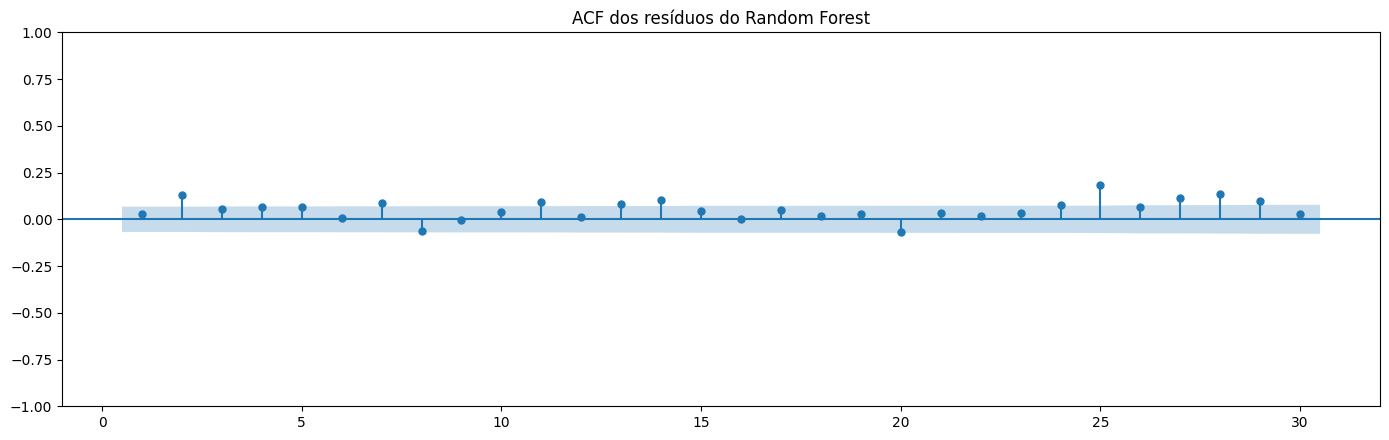

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,0.632732,4.263551e-01,False
7,30.909051,6.462161e-05,True
14,57.321548,3.440505e-07,True
30,142.028655,1.701673e-16,True


In [11]:
usable_acf_lags = min(ACF_LAGS, max(1, len(residuals) // 2 - 1))
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=usable_acf_lags, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do Random Forest')
plt.tight_layout(); plt.show()
usable_ljung_lags = sorted({lag for lag in LJUNG_LAGS if lag < len(residuals)})
ljung_box = acorr_ljungbox(residuals, lags=usable_ljung_lags, return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)